In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml

## note: to import tsne
from sklearn.manifold import TSNE


In [2]:
## Load dataset

mnist = fetch_openml('mnist_784',version=1)

X = mnist.data / 255.0
y = mnist.target

In [3]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [7]:
## select 1000 random points

np.random.seed(42) ## for reproducibility

indices = np.random.choice(range(X.shape[0]), replace=False , size=10000)

X_subset = X.iloc[indices]
y_subset = y.iloc[indices]

In [8]:
X_subset.shape

(10000, 784)

In [9]:
## apply PCA for initial dimensionality reduction

pca=PCA(n_components=2)
X_pca = pca.fit_transform(X_subset)

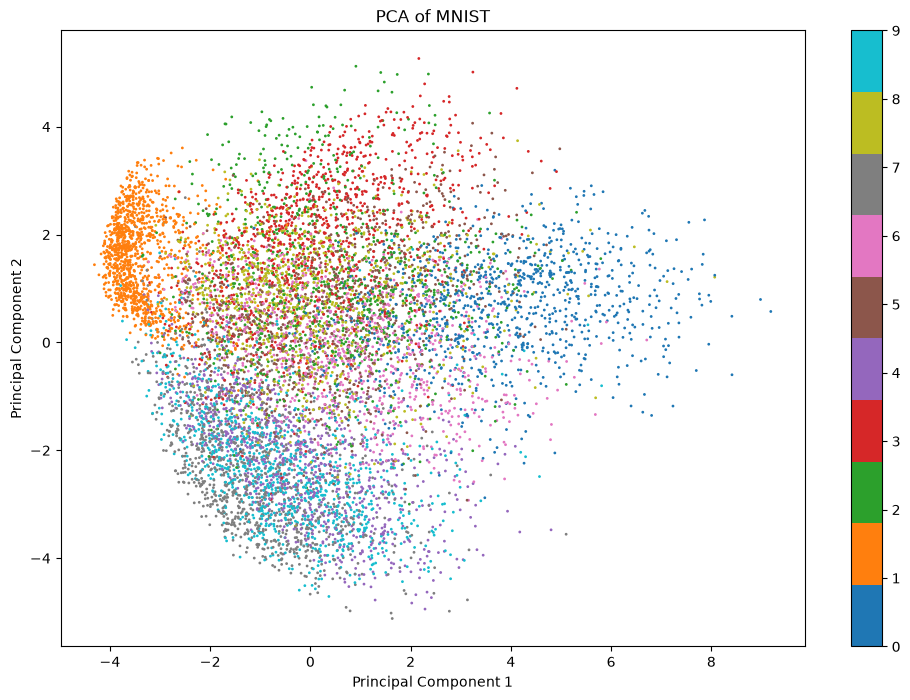

In [11]:
## Plotting with Matplotlib

plt.figure(figsize=(12,8))

scatter = plt.scatter(X_pca[:,0],X_pca[:,1],c=y_subset.astype(int),cmap='tab10',s=1)
plt.colorbar(scatter)
plt.title('PCA of MNIST')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

Hyperparameters of tsne

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    metric="euclidean",
    init="pca",
    random_state=42
)

## n_components

n_components=2

Controls the number of dimensions in the output.

Usually:

- n_components = 2 → 2D visualization
- n_components = 3 → 3D visualization


## perplexity

This is probably the most important t-SNE hyperparameter to understand.

Perplexity roughly controls:

How many neighboring points each point considers when constructing its local neighborhood. It is not exactly the number of neighbors, but you can develop that intuition. Low perplexity perplexity=5 -> t-SNE focuses on very local relationships.

You may see:

- small clusters
- fine local structures
- more fragmented visualization


High perplexity perplexity=50 -> t-SNE considers a broader neighborhood.

Think of it like this :

Low perplexity -> "Who are my closest friends?"

High perplexity -> "Who are the people in my broader social circle?"

## learning_rate

learning_rate="auto"

The learning rate controls how large a step t-SNE takes during optimization. Think of optimization as trying to arrange points so that their relationships in the low-dimensional space match the high-dimensional relationships.

## max_iter

max_iter=1000

Controls the maximum number of optimization iterations.

Iteration 1 -> Move points -> Iteration 2 -> Move points -> ... -> Iteration 1000

## metric

metric="euclidean"

This determines how similarity/distance between high-dimensional samples is calculated.

Other possibilites 'manhattan', 'cosine', 'minkowski' 

## init 

init="pca"

Determines how the initial low-dimensional positions are chosen.

Common options: 

init="pca"

or

init="random"

t-SNE starts from a PCA-based initialization.

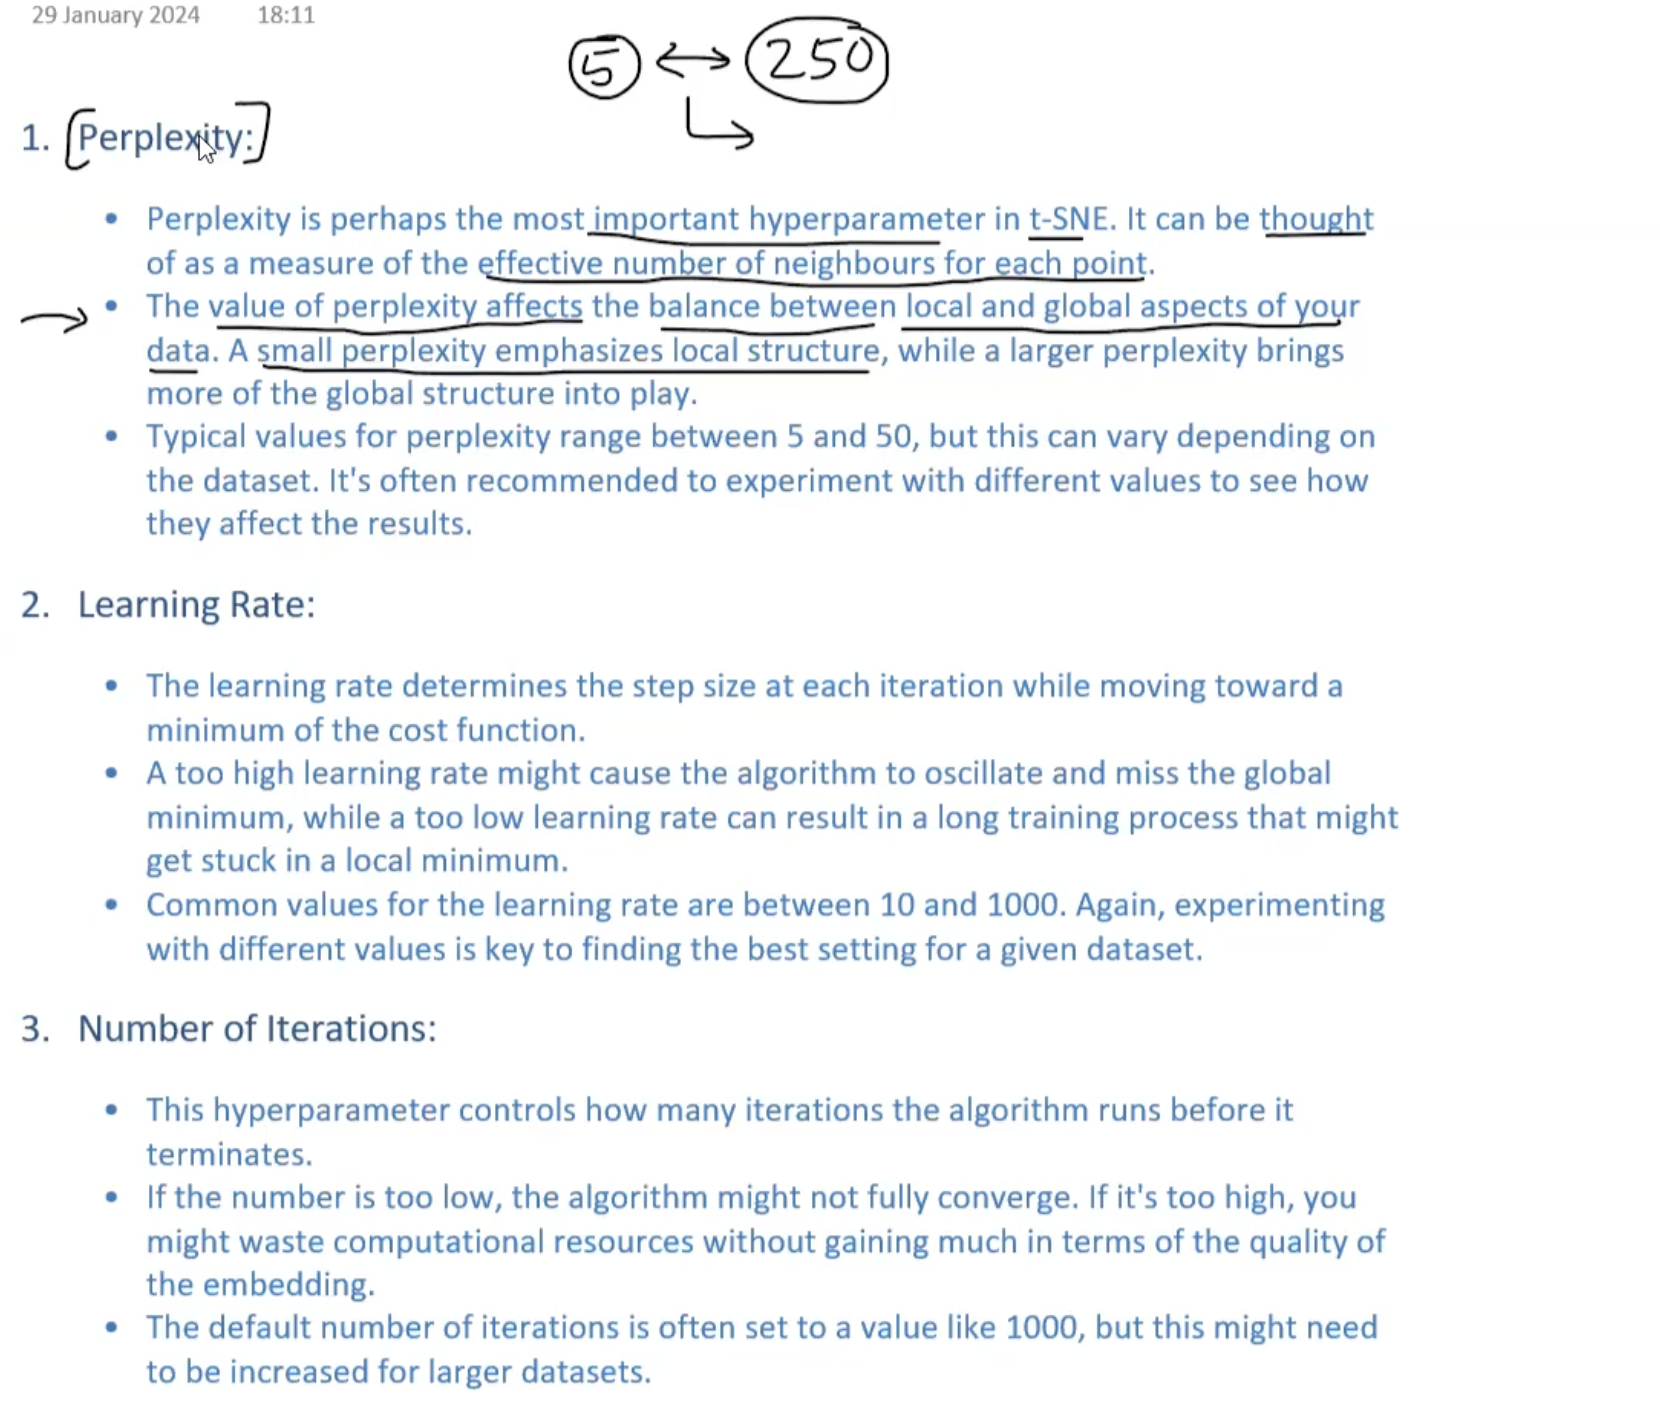

In [15]:
## apply t-sne

tsne=TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca', learning_rate='auto')

X_tsne= tsne.fit_transform(X_subset)

In [12]:
## if perplexity is very low then i am focusing more on the local structure
## if perplexity is very high then I am focusing on global structure

In [16]:
X_tsne.shape

(10000, 2)

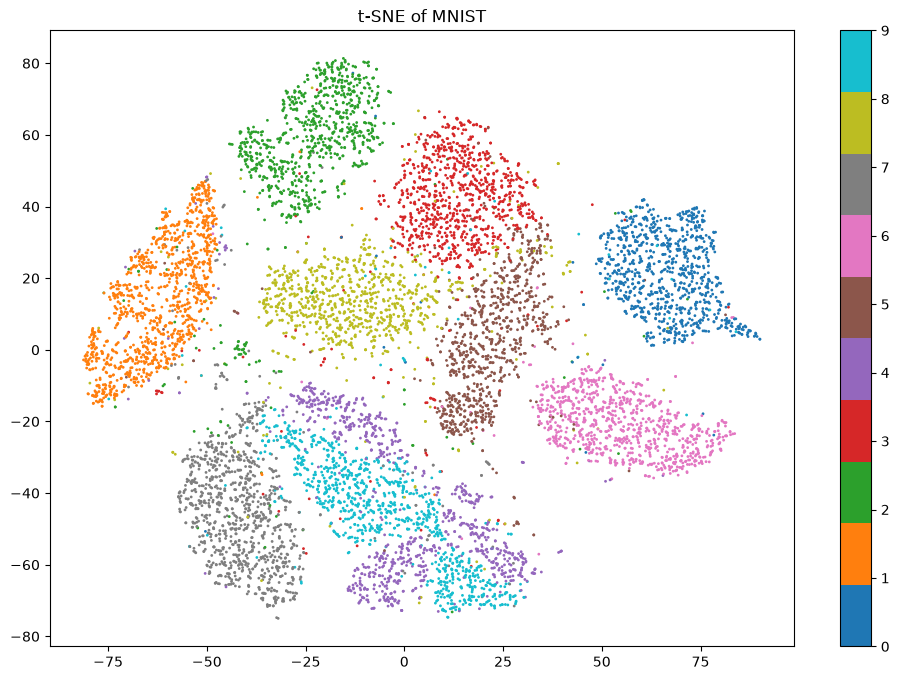

In [17]:
## plot the results

## Plotting with Matplotlib

plt.figure(figsize=(12,8))

scatter = plt.scatter(X_tsne[:,0],X_tsne[:,1],c=y_subset.astype(int),cmap='tab10',s=1)
plt.colorbar(scatter)
plt.title('t-SNE of MNIST')
plt.show()

## Attributes of tsne

In [ ]:
## to get coordinate of every point in low-dimensional space
tsne.embedding_

array([[ -8.382735 ,  15.330675 ],
       [ -1.0723535, -25.266165 ],
       [  9.567202 ,  22.326609 ],
       ...,
       [ 10.485984 ,  62.045322 ],
       [ 38.951584 ,  51.96201  ],
       [  2.7159243,  40.682934 ]], shape=(10000, 2), dtype=float32)

In [19]:
## t-sne final loss value 

tsne.kl_divergence_

1.8178911209106445

In [21]:
tsne.learning_rate_

np.float64(208.33333333333334)

In [22]:
tsne.n_iter_

999

In [23]:
tsne.n_iter_without_progress

300

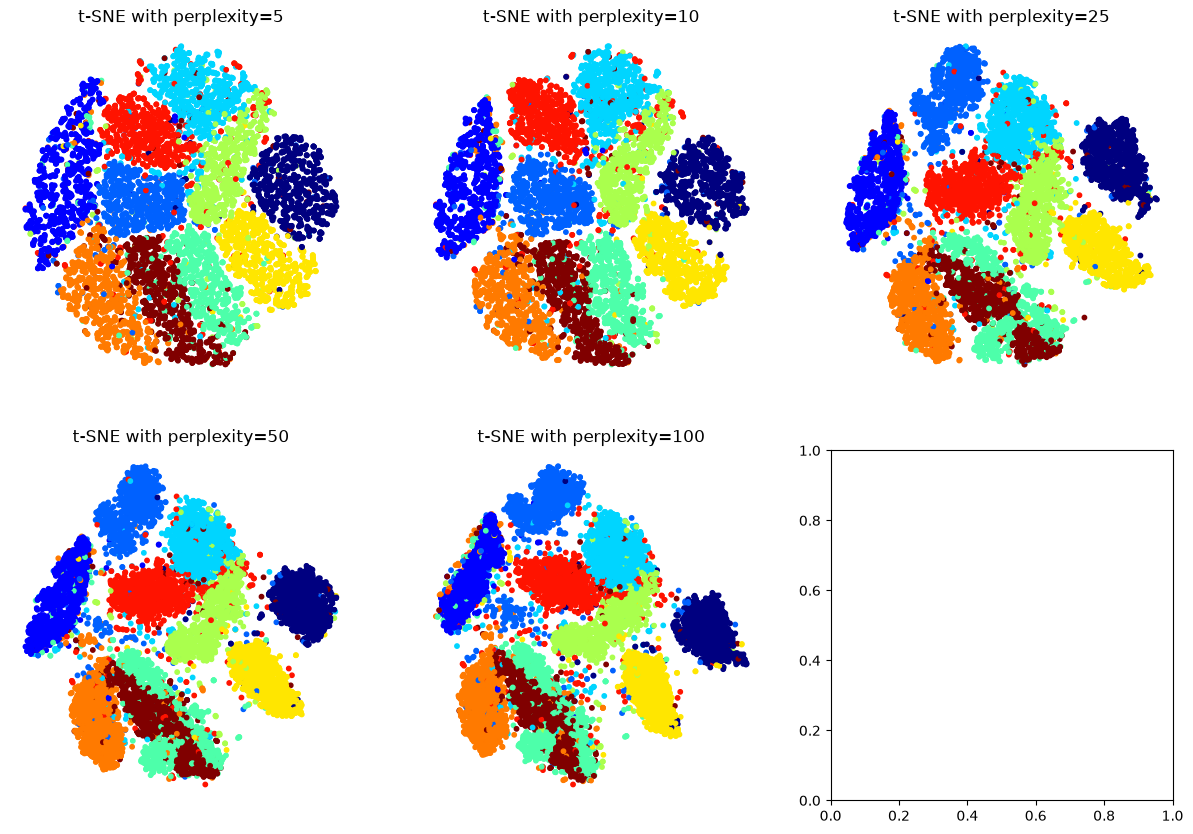

In [24]:
## perplexity values to try

perplexities= [5,10,25,50,100]

## Prepare the plot grid

fig,ax=plt.subplots(2,3,figsize=(15,10))
axes=ax.flatten()

## Apply t-sne with diff perplexity values and plot

for i,perplexity in enumerate(perplexities):
    tsne=TSNE(n_components=2,perplexity=perplexity,max_iter=1000,random_state=42,learning_rate='auto')
    X_tsne=tsne.fit_transform(X_subset)

    ax=axes[i]
    scatter=ax.scatter(X_tsne[:,0],X_tsne[:,1],cmap='jet',c=y_subset.astype(int), s=10)
    ax.set_title(f't-SNE with perplexity={perplexity}')
    ax.axis('off')
    

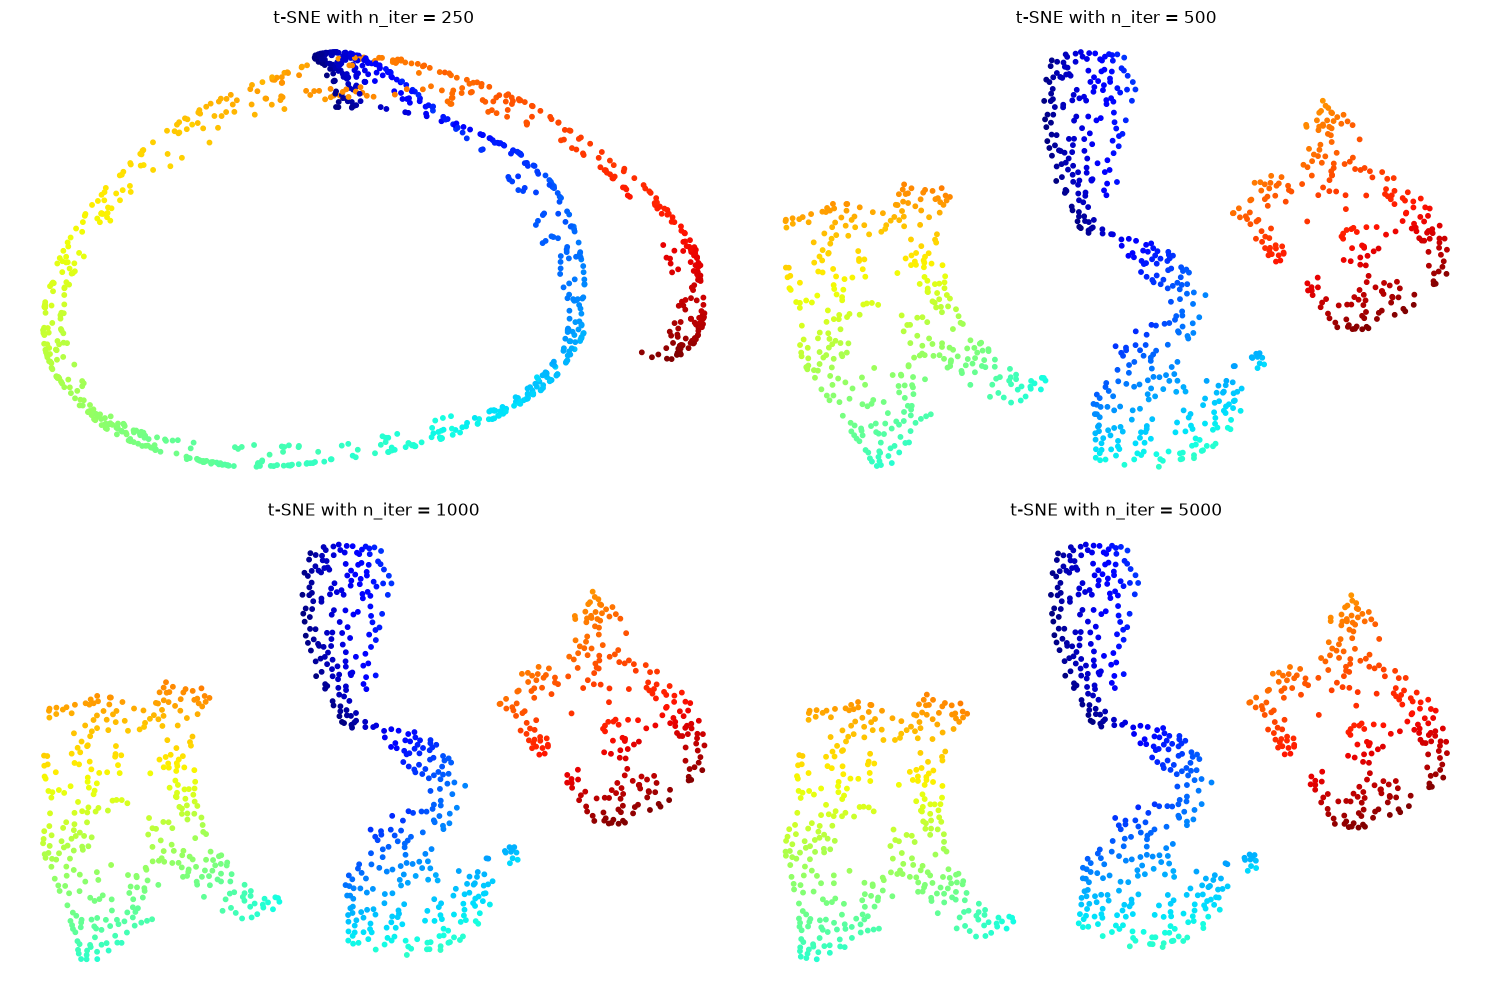

In [2]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Generate a 3D Swiss Roll dataset
X, color = make_swiss_roll(n_samples=1000)

# Perplexity value
perplexity = 50

# Different n_iter values to try
n_iter_values = [250, 500, 1000, 5000]

# Prepare the plot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Apply t-SNE with different n_iter values and plot
for i, n_iter in enumerate(n_iter_values):
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=n_iter, random_state=42)
    X_tsne = tsne.fit_transform(X)

    ax = axes[i]
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap='jet', s=10)
    ax.set_title(f't-SNE with n_iter = {n_iter}')
    ax.axis('off')

# Remove the empty subplot (if any)
for i in range(len(n_iter_values), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


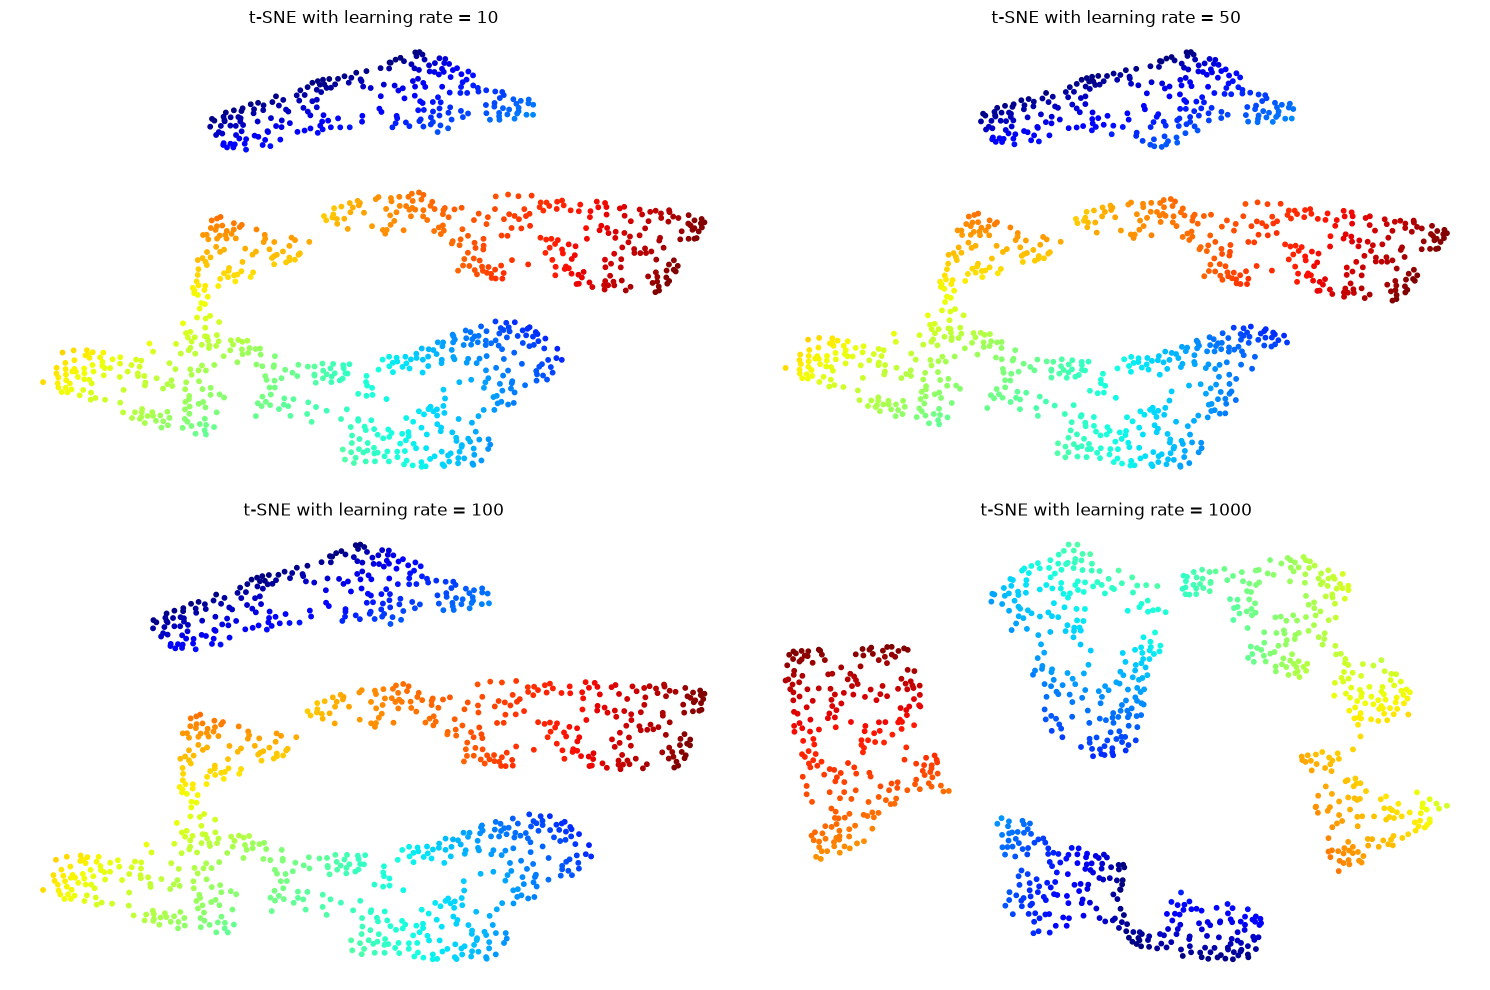

In [4]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Generate a 3D Swiss Roll dataset
X, color = make_swiss_roll(n_samples=1000)

# Perplexity value
perplexity = 50

# Different n_iter values to try
lr_values = [10, 50, 100, 1000]

# Prepare the plot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# Apply t-SNE with different n_iter values and plot
for i, lr in enumerate(lr_values):
    tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=5000, learning_rate=lr, random_state=42)
    X_tsne = tsne.fit_transform(X)

    ax = axes[i]
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap='jet', s=10)
    ax.set_title(f't-SNE with learning rate = {lr}')
    ax.axis('off')

# Remove the empty subplot (if any)
for i in range(len(lr_values), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
